# TEFAP Funding

A short notebook with information about national TEFAP funding and specifics about where TEFAP funds and foods are distributed in Minnesota.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## FY2025 Federal Food Spending

The data are summarized from the United States Department of Agriculture (USDA) Food and Nutrition Service (FNS) [December 2025 Keydata Report](https://www.fns.usda.gov/pd/overview/keydata-dec25).

In [2]:
summary = pd.read_excel("data/usda_food_breakdown_FY2025.xlsx", header=1)
# Drop the total column:
summary.dropna(inplace=True)
# Remove federal administration expenses from breakdown:
summary = summary.loc[summary["Program"] != "Nutrition Programs Administration"]
len(summary)

16

In [3]:
# Rename certain programs for labelling
summary.loc[
    summary["Program"] == "SNAP (Supplemental Nutrition Assistance)", "Program"
] = "SNAP"
summary.loc[
    summary["Program"]
    == "TEFAP Foods (includes Bonus foods for Indian Resr. And the Nutr. Program for the Elderly)",
    "Program",
] = "TEFAP"
summary.loc[
    summary["Program"]
    == "WIC (Women, Infants, and Children) Special Supplemental Nutrition Program",
    "Program",
] = "WIC"

In [4]:
# Add column Expense_percentage
summary["Expense_percentage"] = (summary["Expense"] / summary["Expense"].sum()) * 100
summary[["Category", "Program", "Expense_percentage"]]

summary.groupby("Category", as_index=False).sum("Expense_percentage").sort_values(
    "Expense_percentage", ascending=False
)

,Category,Expense,Expense_percentage
2,SNAP,1.017317e+11,71.486834
0,Child Nutrition Programs,3.058994e+10,21.495550
3,Supplemental Food,8.155717e+09,5.731023
4,USDA Surplus Commodities,1.670997e+09,1.174210
1,Food Donation,1.599313e+08,0.112384


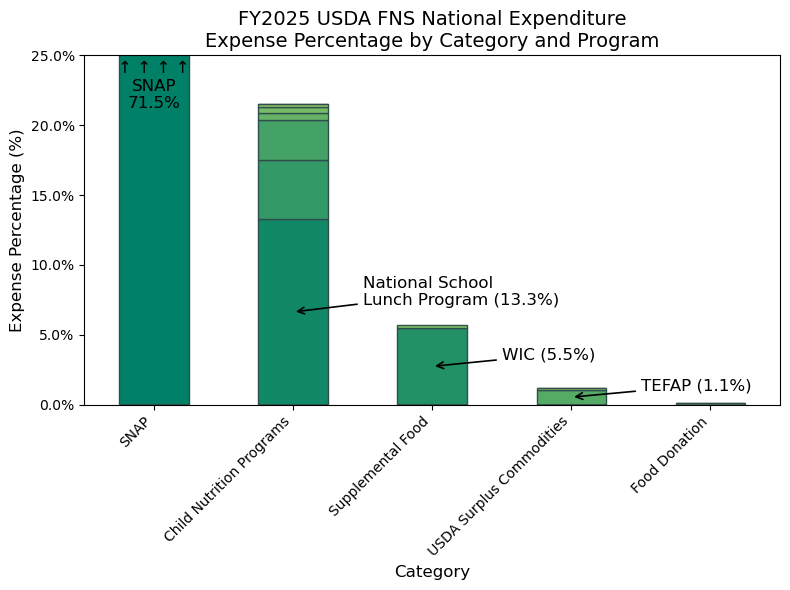

In [5]:
# --- Pivot ---
pivot_df = summary.pivot_table(
    index="Category", columns="Program", values="Expense_percentage", aggfunc="sum"
).fillna(0)

# --- Order ROWS (categories) left to right by total ---
row_order = pivot_df.sum(axis=1).sort_values(ascending=False).index
pivot_df = pivot_df.loc[row_order]

# --- Order COLUMNS (programs) most to least ---
col_order = pivot_df.sum(axis=0).sort_values(ascending=False).index
pivot_df = pivot_df[col_order]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

pivot_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="summer",
    legend=False,
    edgecolor="darkslategray",
)

ax.set_title(
    "FY2025 USDA FNS National Expenditure\nExpense Percentage by Category and Program",
    fontsize=14,
)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Expense Percentage (%)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylim(0, 25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# --- Compute segment midpoints ---
programs_to_label = ["National School Lunch Program", "TEFAP", "WIC"]

cumulative = pd.Series(0.0, index=pivot_df.index)
segment_mids = {}

for prog in pivot_df.columns:
    segment_mids[prog] = cumulative + pivot_df[prog] / 2
    cumulative += pivot_df[prog]

categories = list(pivot_df.index)

for prog in programs_to_label:
    if prog not in pivot_df.columns:
        continue

    best_cat = pivot_df[prog].idxmax()
    x = categories.index(best_cat)
    y_mid = segment_mids[prog][best_cat]
    y_mid_clipped = min(y_mid, 23)
    val = pivot_df[prog][best_cat]

    # Build label with exact percentage
    if prog == "SNAP":
        label = f"SNAP ({val:.1f}%)"
    elif prog == "National School Lunch Program":
        label = f"National School\nLunch Program ({val:.1f}%)"
    elif prog == "TEFAP":
        label = f"TEFAP ({val:.1f}%)"
    elif prog == "WIC":
        label = f"WIC ({val:.1f}%)"

    ax.annotate(
        label,
        xy=(x, y_mid_clipped),
        xytext=(x + 0.5, y_mid_clipped + 0.5),
        fontsize=12,
        arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
        ha="left",
    )

# --- Mark clipped SNAP bar ---
if "SNAP" in pivot_df.columns:
    snap_cat = pivot_df["SNAP"].idxmax()
    snap_val = pivot_df["SNAP"][snap_cat]
    x = categories.index(snap_cat)
    ax.text(
        x,
        21.0,
        f"↑ ↑ ↑ ↑\nSNAP\n{snap_val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        # fontweight="bold",
        color="black",
    )

plt.tight_layout()
plt.show()

TEFAP funding makes up a small fraction of FNS spending on food help.

## CY2025 Minnesota TEFAP Case Distribution

The data are from a 04/08/26 MN DCYF data request.

In [6]:
mn_shelves = pd.read_excel("data/DCYF_Data_Request_4_8_26.xlsx", sheet_name=1)
mn_shelves = mn_shelves.drop(index=[499, 500])
mn_shelves = mn_shelves.rename(
    columns={
        "TEFAP Distribution Site Name": "site",
        "TEFAP Cases Distributed 2025": "cases_distributed",
    }
)
len(mn_shelves)

499

In [7]:
# checking to see if there are any non-integers:
mn_shelves.loc[mn_shelves["cases_distributed"] % 1 != 0, "cases_distributed"].count()

np.int64(0)

In [8]:
# casting to int
mn_shelves["cases_distributed"] = mn_shelves["cases_distributed"].astype("int")

In [9]:
# Total TEFAP cases distributed
mn_shelves["cases_distributed"].sum()

np.int64(512608)

In [10]:
# Ten largest food shelves
mn_shelves.sort_values("cases_distributed", ascending=False).head(10)

,site,cases_distributed
276,Manna Market Substance,24327
73,Channel One Food Shelf,15856
472,"VEAP, Inc.",10794
342,Open Cupboard,10163
205,Hope For The Community,9891
231,Individuals Second Harvest Food Shelf,9500
429,The Corner Shelf,8088
471,Valley Outreach,7668
246,Keystone Community Food Center,7500
91,Community Pathways of Steele County-Owatonna,7124


In [15]:
# Ten smallest food shelves by cases received
mn_shelves.loc[:, ["site", "cases_distributed"]].sort_values("cases_distributed").head(
    10
)

,site,cases_distributed
83,Comet's Cupboard,1
223,INACTIVE Grace Ministries,1
442,The Salvation Army Duluth,2
343,Open Hands Midway Food Shelf,2
494,"Women's Advocates, Inc.",3
301,Missions Inc. - Hart House,3
100,Dakota Woodlands,4
414,Southland Faith Food Shelf,4
5,Anna Marie's Alliance,4
114,Eden Valley Food Shelf,6


In [11]:
mn_shelves.loc[mn_shelves["site"] == "Manna Market Substance", "county"] = "Hennepin"
mn_shelves.loc[mn_shelves["site"] == "Channel One Food Shelf", "county"] = "Olmsted"
mn_shelves.loc[mn_shelves["site"] == "VEAP, Inc.", "county"] = "Hennepin"
mn_shelves.loc[mn_shelves["site"] == "Open Cupboard", "county"] = "Washington"
mn_shelves.loc[mn_shelves["site"] == "Hope For The Community", "county"] = "Anoka"

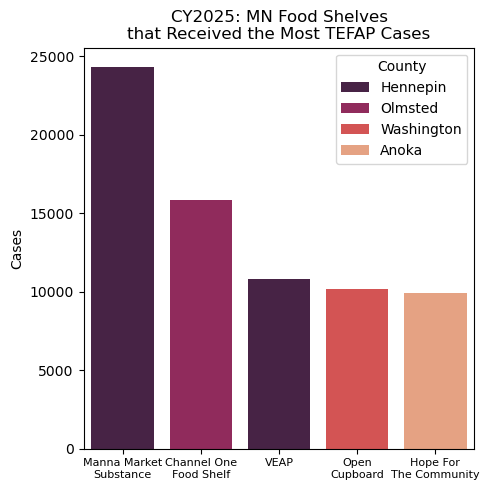

In [12]:
top5 = mn_shelves.sort_values("cases_distributed", ascending=False).head(5)
top5.loc[top5["site"] == "Manna Market Substance", "site"] = "Manna Market\nSubstance"
top5.loc[top5["site"] == "Channel One Food Shelf", "site"] = "Channel One\nFood Shelf"
top5.loc[top5["site"] == "VEAP, Inc.", "site"] = "VEAP"
top5.loc[top5["site"] == "Open Cupboard", "site"] = "Open\nCupboard"
top5.loc[top5["site"] == "Hope For The Community", "site"] = "Hope For\nThe Community"

fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=top5,
    x="site",
    y="cases_distributed",
    hue="county",
    palette="rocket",
    ax=ax,
)

ax.tick_params(axis="x", labelsize=8)
ax.set_title("CY2025: MN Food Shelves\nthat Received the Most TEFAP Cases")
ax.set_xlabel("")
ax.set_ylabel("Cases")
plt.legend(title="County")
plt.tight_layout()
plt.show()